# Chronos-2 vs Chronos-T5 — Head-to-Head (Benchmark II)

**Saudi Aramco — time-series foundation-model evaluation · comparison layer**

An **apples-to-apples** comparison of two time-series foundation models — the incumbent
**Chronos-T5** and the newer **Chronos-2** — on the Chronos paper's **Benchmark II**
(25 held-out datasets). This is the *comparison* project (`chronos2_t5/`): it does **not**
run a model. Every number here is recomputed from the result CSVs the two sibling
engine-projects already produced, on one shared gluonts pipeline, so the measured gap
reflects real model quality, not a benchmarking artifact.

> **TL;DR** — Zero-shot, Chronos-2 is **~18 % lower WQL** than Chronos-T5, wins **23/25**
> datasets, and is **~7–12× faster**. Once *both* models are LoRA fine-tuned, they **tie**
> (Wilcoxon p > 0.1). So Chronos-2's edge is out-of-the-box, and its practical value is
> *not needing* fine-tuning.

### The three parallel projects

| project | role | this notebook uses |
| --- | --- | --- |
| `Chronos_benchmark/` | **Chronos-T5** engine — zero-shot + one-shot (LoRA) | its `results/*.csv` |
| `Chronos2/` | **Chronos-2** engine — zero-shot (uni + cross-learning) + one-shot (LoRA) | its `results/*.csv` |
| `chronos2_t5/` | **this** — head-to-head, leaderboard, dominance, robustness | aggregates the two |

### Three design principles (why the comparison is fair)

1. **Single source of truth** — data loading + metrics live in each engine's
   `run_zeroshot_*.py`; zero-shot, one-shot and cross-learning all call it.
2. **Byte-identical datasets** — both engines share the same `datasets_lib.py`
   registry (same 25 `(dataset, horizon)` pairs, `MAX_SERIES = 1000`).
3. **One fixed denominator** — every relative score divides by the paper's official
   **Seasonal-Naive** numbers, so scores stay comparable to the published leaderboard.


## 1. Environment & data

No GPU and no model needed: this notebook only reads the committed result CSVs and
displays committed figures. We locate the repo root portably (the folder that holds all
three projects) and wire up the paths.

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np, pandas as pd
from scipy.stats import gmean
from IPython.display import Image, Markdown, display

# Locate the repo root portably: walk up until we see all three sibling projects.
_here = Path.cwd()
for _c in (_here, *_here.parents):
    if all((_c / p).is_dir() for p in ("Chronos2", "Chronos_benchmark", "chronos2_t5")):
        ROOT = _c; break
else:
    raise FileNotFoundError("repo root (with Chronos2/ Chronos_benchmark/ chronos2_t5/) not found")

C2   = ROOT / "Chronos2"          # Chronos-2 engine project
T5   = ROOT / "Chronos_benchmark" # Chronos-T5 engine project
CMP  = ROOT / "chronos2_t5"       # this comparison project
ZS   = CMP / "zero-shot"
OS_  = CMP / "one-shot"

def show(path, width=760):
    """Display a committed figure if present, else note it is regenerable."""
    p = Path(path)
    if p.exists():
        display(Image(filename=str(p), width=width))
    else:
        display(Markdown(f"*(figure `{p.relative_to(ROOT)}` not committed — "
                         f"regenerate with the script noted above)*"))

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("repo root located (Chronos2 / Chronos_benchmark / chronos2_t5 found)")
print("C2 results:", (C2 / "results").exists(), "| T5 results:", (T5 / "results").exists())

repo root located (Chronos2 / Chronos_benchmark / chronos2_t5 found)
C2 results: True | T5 results: True


## 2. The aggregated relative score (the paper's headline metric)

The Chronos papers aggregate across datasets with the **geometric mean of
`model / Seasonal-Naive`** — scale-free, lower is better, `1.0` = Seasonal-Naive. We
recompute it here from the raw per-dataset CSVs so you can see exactly where the headline
comes from. Two metrics:

* **WQL** — weighted quantile (pinball) loss over the 9-quantile grid 0.1–0.9 (primary,
  probabilistic).
* **MASE** — mean abs error ÷ in-sample Seasonal-Naive error (point).

In [2]:
# Per-dataset results from the two engines (+ the shared Seasonal-Naive denominator).
c2  = pd.read_csv(C2 / "results" / "zeroshot_chronos2_results.csv")
t5  = pd.read_csv(T5 / "results" / "zeroshot_official_results.csv").set_index("dataset")
sn  = pd.read_csv(T5 / "reference" / "seasonal-naive-zero-shot.csv").set_index("dataset")

c2_uni = c2[c2["mode"] == "univariate"].set_index("dataset")
c2_cl  = c2[c2["mode"] == "cross_learning"].set_index("dataset")
common = c2_uni.index.intersection(t5.index).intersection(sn.index)
print(f"{len(common)} datasets compared on the identical pipeline")

def agg(df):
    """gmean over datasets of (model / Seasonal-Naive) for MASE and WQL."""
    return (df.loc[common, ["MASE", "WQL"]] / sn.loc[common, ["MASE", "WQL"]]).apply(gmean)

headline = pd.DataFrame({
    "Chronos-T5 zero-shot":      agg(t5),
    "Chronos-2 zero-shot (uni)": agg(c2_uni),
    "Chronos-2 zero-shot (CL)":  agg(c2_cl),
}).T[["WQL", "MASE"]]
headline["WQL vs T5"]  = (headline["WQL"]  / headline.loc["Chronos-T5 zero-shot", "WQL"]  - 1) * 100
headline["MASE vs T5"] = (headline["MASE"] / headline.loc["Chronos-T5 zero-shot", "MASE"] - 1) * 100
print("Aggregated relative score (gmean of model / Seasonal-Naive; lower = better).")
print("'vs T5' columns: % change relative to Chronos-T5 zero-shot (negative = better).")
headline.round(3)

25 datasets compared on the identical pipeline
Aggregated relative score (gmean of model / Seasonal-Naive; lower = better).
'vs T5' columns: % change relative to Chronos-T5 zero-shot (negative = better).


,WQL,MASE,WQL vs T5,MASE vs T5
Chronos-T5 zero-shot,0.6870,0.8520,0.0000,0.0000
Chronos-2 zero-shot (uni),0.5880,0.7730,-14.4170,-9.3110
Chronos-2 zero-shot (CL),0.5630,0.7510,-18.0040,-11.9350


Chronos-2 cross-learning lands at **WQL ≈ 0.563 / MASE ≈ 0.751** vs Chronos-T5's
**0.687 / 0.852** — about **−18 % WQL** and **−12 % MASE**. Plain univariate C2 already
beats T5; cross-learning adds a further ~4 % WQL on top.

## 3. Leaderboard — win rate, skill score, runtime

The Chronos-2-report-style leaderboard (`zero-shot/benchmark/`, produced by
`scripts/benchmark_table.py`). **Win rate** = share of pairwise (dataset, opponent)
comparisons a model wins; **skill** = `100·(1 − gmean(model / Seasonal-Naive))`. Both:
higher is better. Runtime is the median per-dataset forecast time.

In [3]:
lb = pd.read_csv(ZS / "benchmark" / "benchmark_leaderboard.csv", index_col=0)
display(lb[["WinRate_WQL", "Skill_WQL", "WinRate_MASE", "Skill_MASE",
            "MedianRuntime_s"]].round(2))

,WinRate_WQL,Skill_WQL,WinRate_MASE,Skill_MASE,MedianRuntime_s
"Chronos-2 (zs, CL)",75.4000,43.7000,72.0000,24.9000,0.2900
"Chronos-2 (1s, CL-eval)",66.9000,38.6000,55.4000,19.1000,0.5800
"Chronos-2 (zs, uni)",62.3000,41.2000,60.6000,22.7000,0.2200
"Chronos-2 (1s, CLtrain)",59.4000,39.1000,53.1000,19.8000,0.5800
"Chronos-2 (1s, uni)",53.7000,37.2000,51.4000,19.2000,0.5000
Chronos-T5 (1s),52.0000,40.4000,63.4000,24.3000,3.7600
Chronos-T5 (zs),25.7000,31.3000,25.7000,14.8000,5.7800
Seasonal Naive,4.6000,0.0000,18.3000,0.0000,NaN


Reading it: **Chronos-2 (zs, CL)** tops both metrics (WQL win-rate 75.4, skill
43.7) and is ~**20× faster** than Chronos-T5 zero-shot (0.29 s vs 5.78 s median). Note
Chronos-T5 *one-shot* is competitive on skill — fine-tuning largely closes the gap,
foreshadowing the one-shot tie in §6.

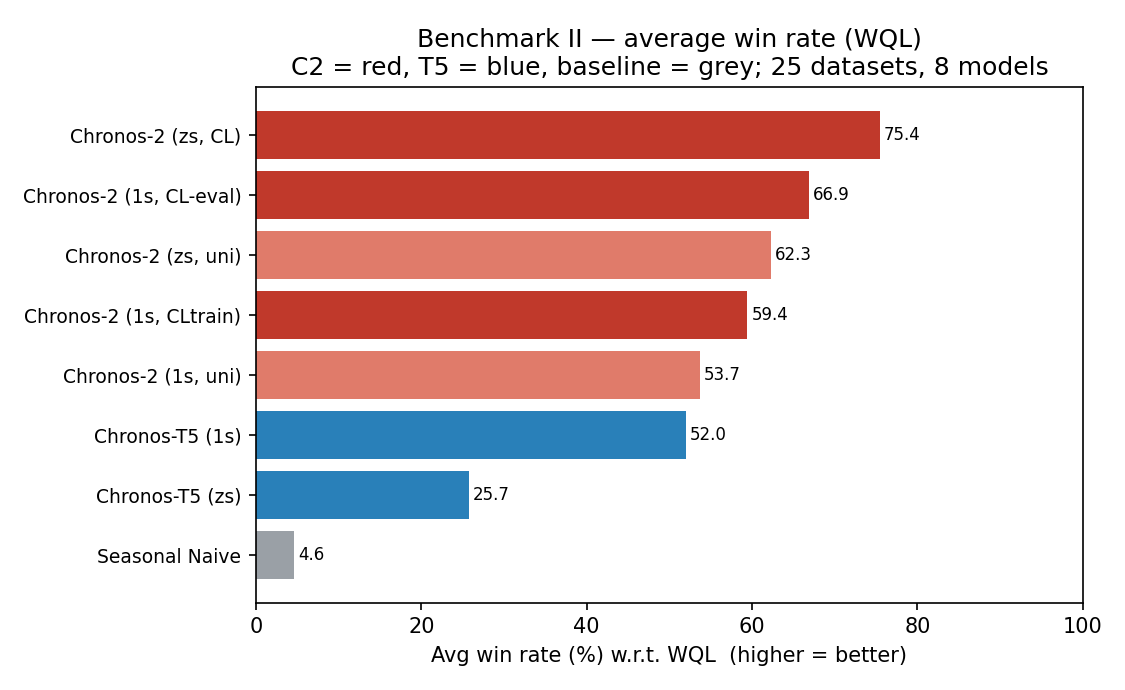

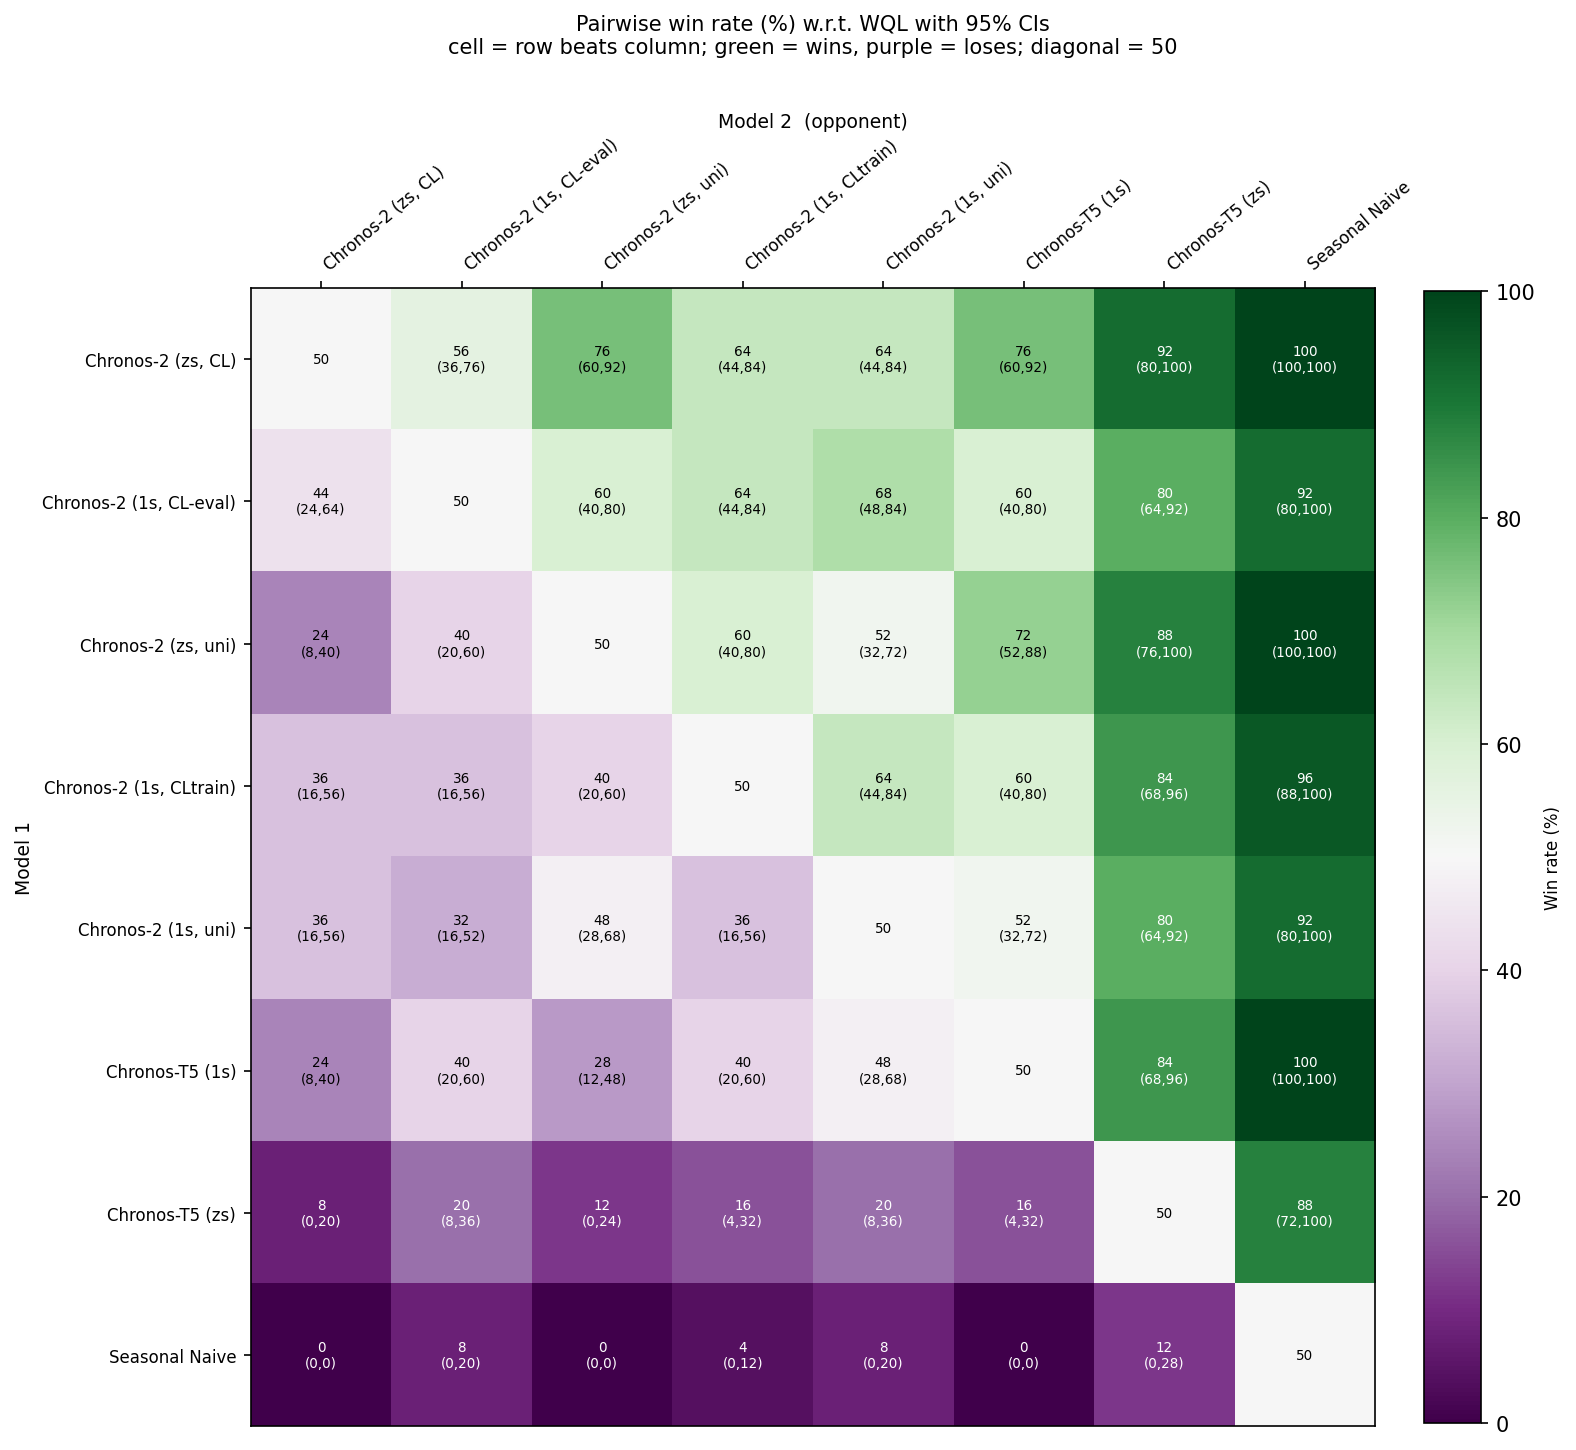

In [4]:
# Win-rate bars and the full pairwise win-rate matrix (committed figures).
show(ZS / "benchmark" / "winrate_wql.png")
show(ZS / "benchmark" / "pairwise_winrate_wql.png")

## 4. Aggregate dashboard + per-dataset dominance

The head-to-head dashboard (`zero-shot/headtohead/`, from `scripts/compare_zeroshot.py`):
accuracy scatter, aggregated relative score, forecast time, and peak GPU memory in one
view.

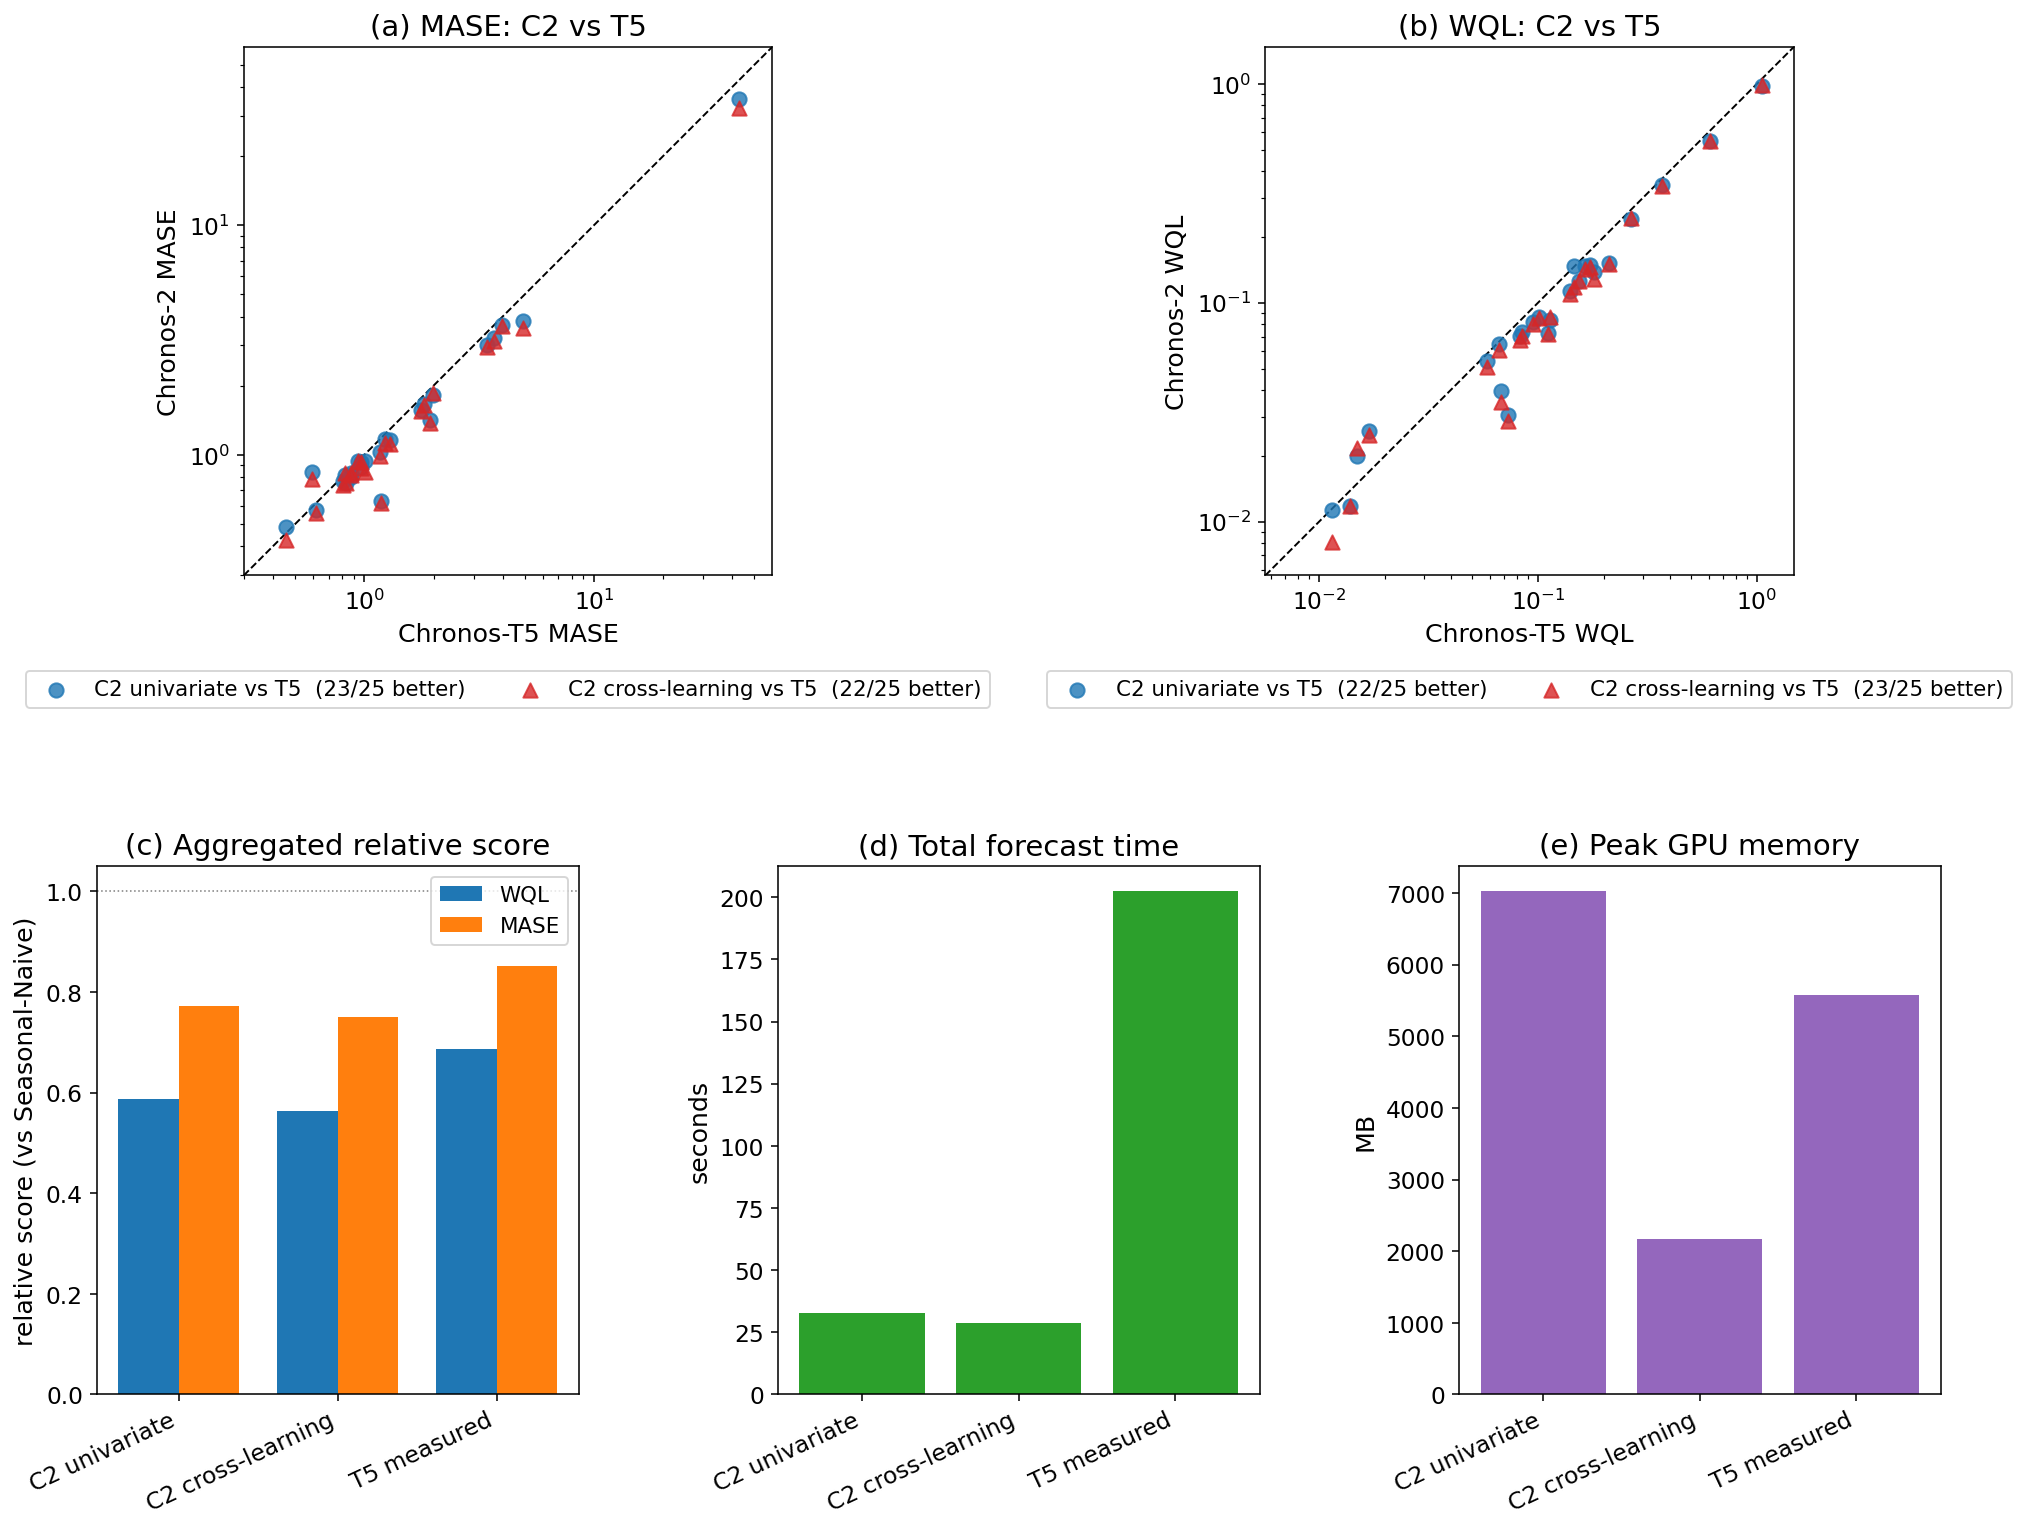

In [5]:
show(ZS / "headtohead" / "c2_vs_t5_dashboard.png", width=900)

Per dataset, how often does Chronos-2 (cross-learning) beat Chronos-T5 zero-shot?

In [6]:
per = pd.DataFrame({
    "T5_WQL": t5.loc[common, "WQL"], "C2CL_WQL": c2_cl.loc[common, "WQL"],
    "T5_MASE": t5.loc[common, "MASE"], "C2CL_MASE": c2_cl.loc[common, "MASE"],
})
per["C2_wins_WQL"]  = per["C2CL_WQL"]  < per["T5_WQL"]
per["C2_wins_MASE"] = per["C2CL_MASE"] < per["T5_MASE"]
print(f"Chronos-2 (CL) beats Chronos-T5 on WQL : {per['C2_wins_WQL'].sum()}/{len(per)} datasets")
print(f"Chronos-2 (CL) beats Chronos-T5 on MASE: {per['C2_wins_MASE'].sum()}/{len(per)} datasets")
per.round(4)

Chronos-2 (CL) beats Chronos-T5 on WQL : 23/25 datasets
Chronos-2 (CL) beats Chronos-T5 on MASE: 22/25 datasets


,T5_WQL,C2CL_WQL,T5_MASE,C2CL_MASE,C2_wins_WQL,C2_wins_MASE
dataset,,,,,,
monash_australian_electricity,0.0724,0.0289,1.1849,0.6174,True,True
monash_cif_2016,0.0115,0.0081,1.0017,0.8374,True,True
monash_car_parts,1.0505,0.9848,0.8768,0.8340,True,True
monash_covid_deaths,0.0673,0.0350,42.7023,32.5474,True,True
dominick,0.3686,0.3401,0.9398,0.9409,True,False
ercot,0.0170,0.0249,0.5922,0.7846,False,False
exchange_rate,0.0138,0.0118,1.9954,1.8491,True,True
monash_fred_md,0.0149,0.0216,0.4533,0.4258,False,True
monash_hospital,0.0583,0.0510,0.8068,0.7401,True,True


## 5. Cross-learning — Chronos-2's in-context lever

Cross-learning (one shared attention group per batch) is a knob Chronos-T5 lacks. How
much does it add over plain univariate C2, and where?

In [7]:
cl = pd.DataFrame({
    "WQL_uni": c2_uni.loc[common, "WQL"], "WQL_CL": c2_cl.loc[common, "WQL"],
    "MASE_uni": c2_uni.loc[common, "MASE"], "MASE_CL": c2_cl.loc[common, "MASE"],
})
cl["WQL_gain_%"]  = (1 - cl["WQL_CL"]  / cl["WQL_uni"])  * 100   # + = CL helped
cl["MASE_gain_%"] = (1 - cl["MASE_CL"] / cl["MASE_uni"]) * 100
print(f"Cross-learning improves WQL on {(cl['WQL_gain_%'] > 0).sum()}/{len(cl)} datasets "
      f"(mean {cl['WQL_gain_%'].mean():.1f}%).")
cl.sort_values("WQL_gain_%", ascending=False).round(2)

Cross-learning improves WQL on 19/25 datasets (mean 3.9%).


,WQL_uni,WQL_CL,MASE_uni,MASE_CL,WQL_gain_%,MASE_gain_%
dataset,,,,,,
monash_cif_2016,0.0100,0.0100,0.9400,0.8400,28.3000,10.6200
monash_m1_monthly,0.1500,0.1200,1.0300,0.9800,19.2500,4.1100
monash_covid_deaths,0.0400,0.0300,35.4300,32.5500,11.7100,8.1400
monash_m1_yearly,0.1400,0.1300,3.8300,3.5500,6.6600,7.2600
monash_tourism_quarterly,0.0600,0.0600,1.5700,1.5500,5.9600,0.9400
monash_australian_electricity,0.0300,0.0300,0.6300,0.6200,5.9100,1.5500
monash_hospital,0.0500,0.0500,0.7700,0.7400,5.3600,4.1700
monash_m3_quarterly,0.0700,0.0700,1.1600,1.1200,4.5600,4.0000
ercot,0.0300,0.0200,0.8400,0.7800,4.3300,6.7900


Cross-learning helps most on **short-history** datasets (m1 family, cif_2016,
covid_deaths) where borrowing across series compensates for little per-series context —
exactly the report's Benchmark II finding. The benefit-vs-length trend
(`zero-shot/cl_length/`, from `scripts/cl_benefit_vs_length.py`):

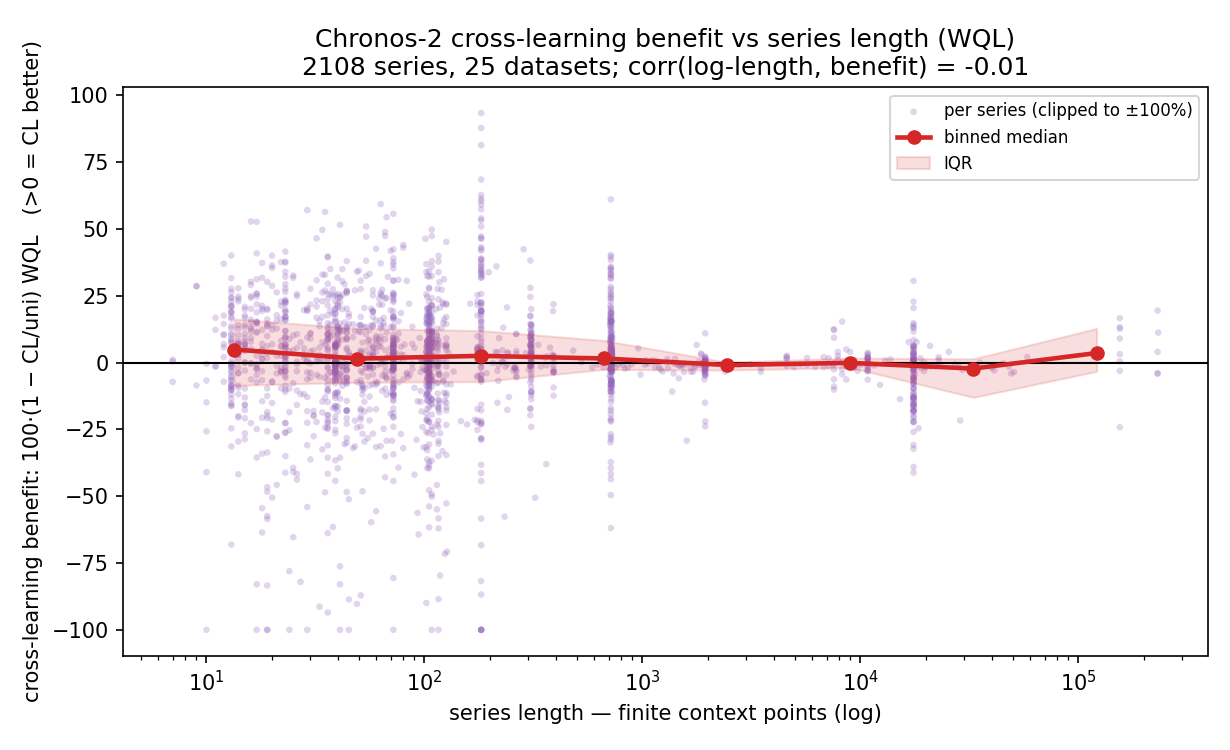

In [8]:
show(ZS / "cl_length" / "cl_benefit_vs_length_wql.png")

## 6. One-shot (LoRA) head-to-head — a statistical tie

Now fine-tune *both* models with LoRA under an identical HPO protocol and identical eval,
**univariate on both sides** (`one-shot/`, `scripts/head_to_head.py`). Does fine-tuning
change the winner?

In [9]:
h2h = pd.read_csv(OS_ / "results" / "head_to_head.csv", index_col=0)
# Aggregate relative score for the fine-tuned models (already ratios vs SN in the report).
from scipy.stats import wilcoxon
agg_os = pd.DataFrame({
    "C2 one-shot (uni)": [gmean(h2h["WQL_C2"]), gmean(h2h["MASE_C2"])],
    "T5 one-shot (uni)": [gmean(h2h["WQL_T5"]), gmean(h2h["MASE_T5"])],
}, index=["WQL", "MASE"]).T
display(agg_os.round(3))
for m in ["WQL", "MASE"]:
    c2v, t5v = h2h[f"{m}_C2"], h2h[f"{m}_T5"]
    p = wilcoxon(c2v, t5v).pvalue
    wins = int((c2v < t5v).sum())
    print(f"{m}: C2 wins {wins}/{len(h2h)}  |  gmean(C2/T5)={gmean(c2v/t5v):.3f}  |  "
          f"Wilcoxon p={p:.3f}  ->  {'TIE (not significant)' if p > 0.05 else 'significant'}")

,WQL,MASE
C2 one-shot (uni),0.0920,1.4010
T5 one-shot (uni),0.0880,1.3140


WQL: C2 wins 13/25  |  gmean(C2/T5)=1.053  |  Wilcoxon p=0.653  ->  TIE (not significant)
MASE: C2 wins 10/25  |  gmean(C2/T5)=1.067  |  Wilcoxon p=0.120  ->  TIE (not significant)


Once both are fine-tuned the models are **within noise** (Wilcoxon p > 0.1 on both
metrics). Fine-tuning does not change the winner — **so there is no need to fine-tune
Chronos-2**; its advantage is the zero-shot regime above. The committed one-shot
figures:

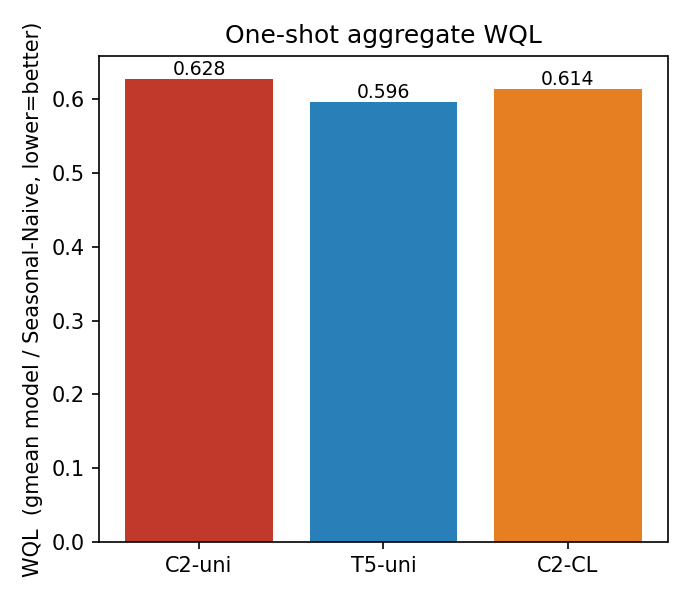

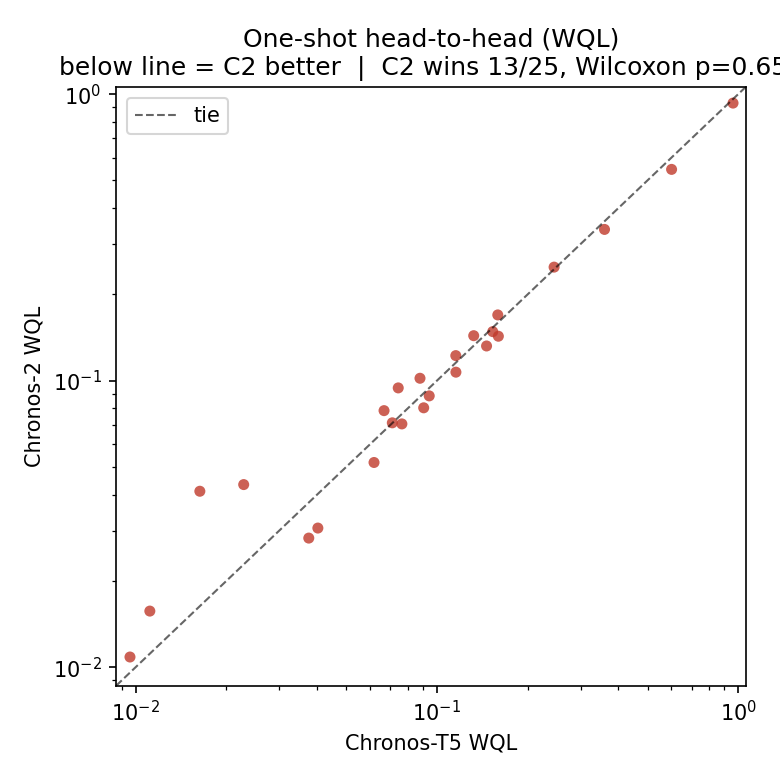

In [10]:
show(OS_ / "plots" / "agg_wql.png")
show(OS_ / "plots" / "h2h_scatter_wql.png")

## 7. The full picture — all seven settings

`one-shot/scripts/summary_matrix.py` places every setting (C2/T5 × zero-/one-shot ×
uni/CL) on one per-dataset heatmap, so the regimes are directly comparable.

Aggregated WQL (gmean of relative score, lower = better) — best regime first:


,WQL
C2 zs-CL,0.5630
C2 zs-uni,0.5880
T5 1s,0.5960
C2 1s-CLtrain,0.6090
C2 1s-CLeval,0.6140
C2 1s-uni,0.6280
T5 zs,0.6870


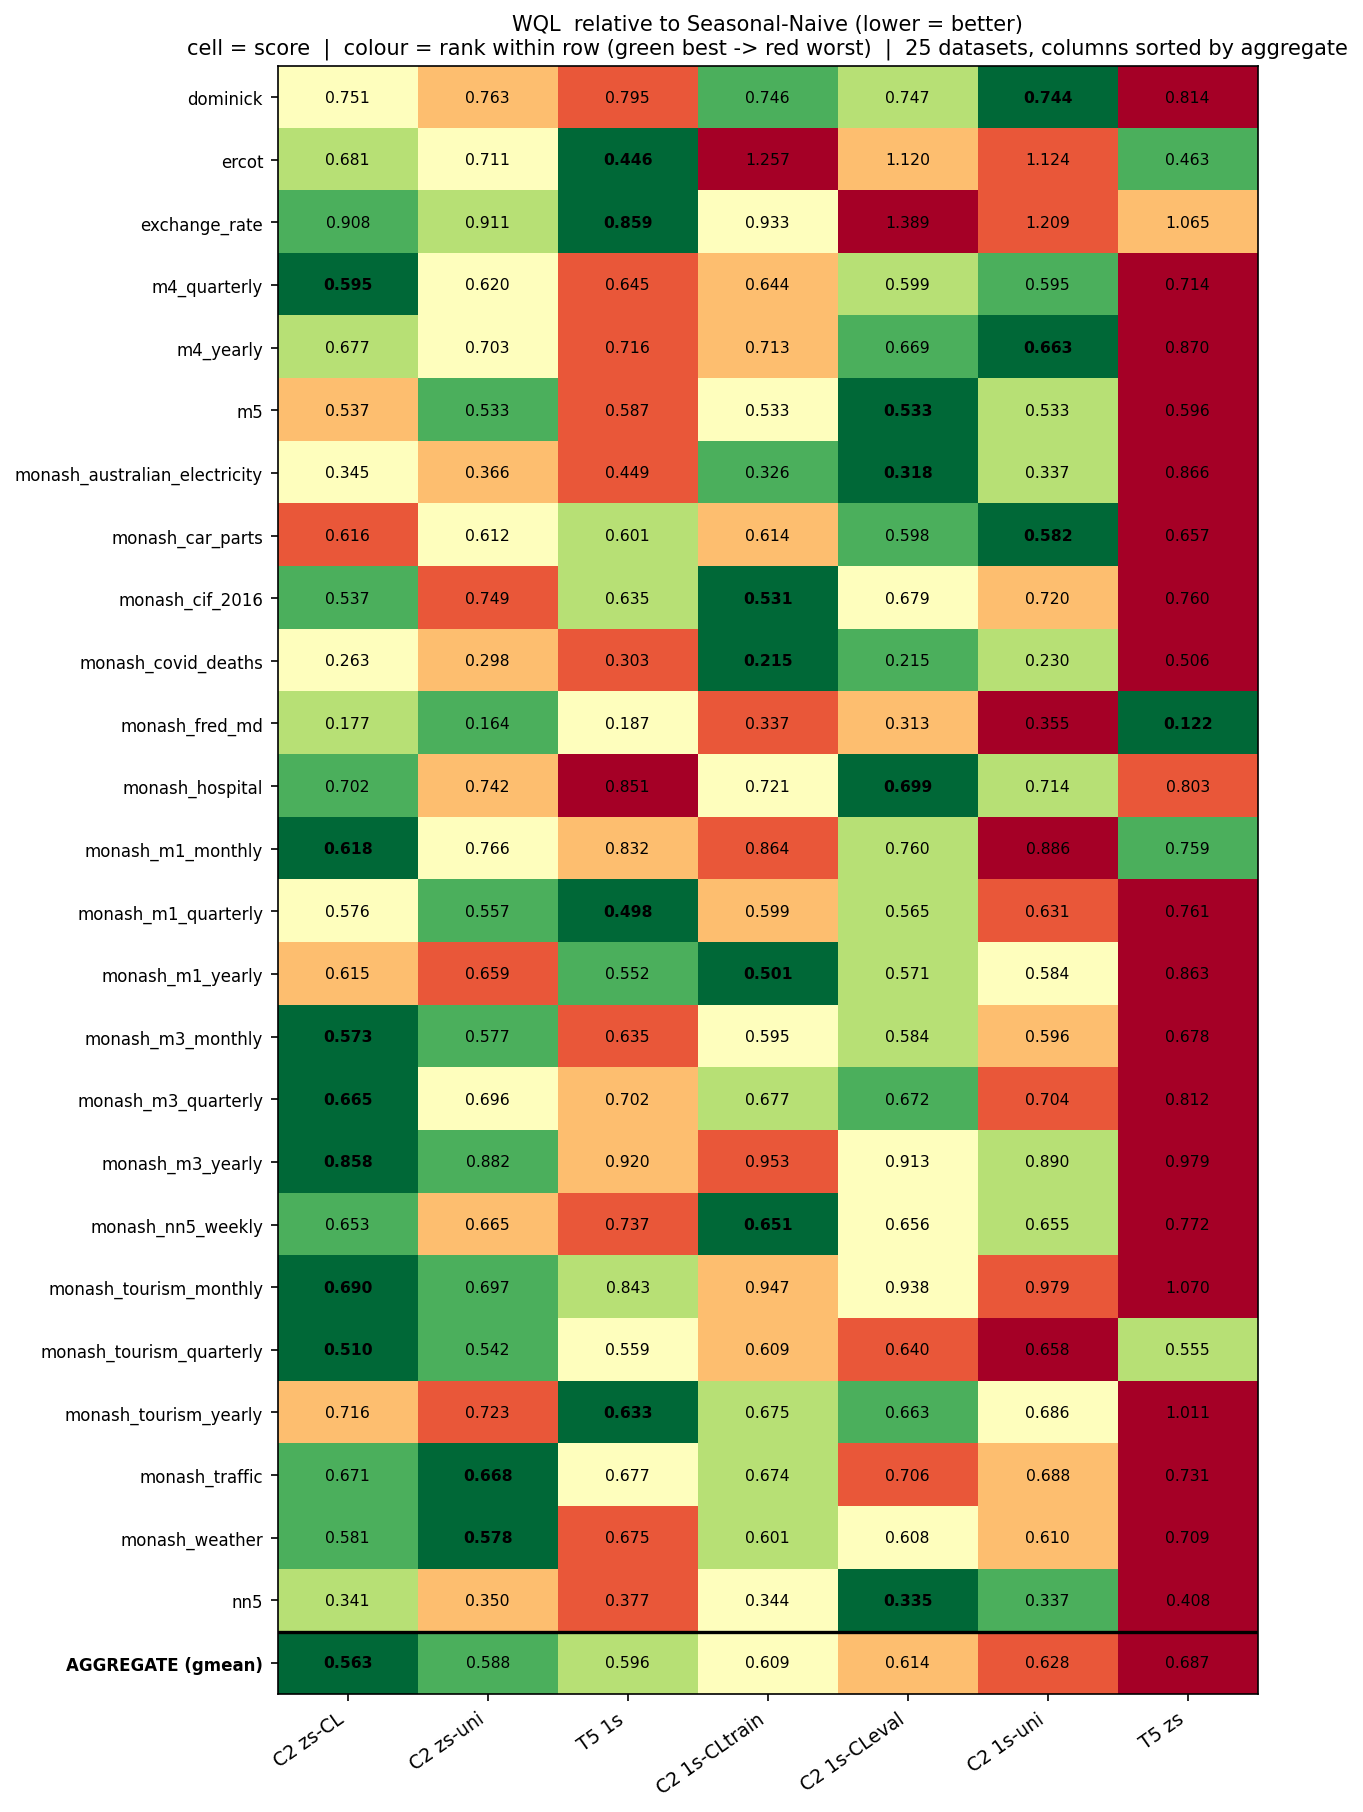

In [11]:
sm = pd.read_csv(OS_ / "results" / "summary_matrix.csv", header=[0, 1], index_col=0)
# Aggregate (gmean) across datasets for each setting, WQL.
wql_cols = sm["WQL"].apply(gmean).sort_values()
print("Aggregated WQL (gmean of relative score, lower = better) — best regime first:")
display(wql_cols.round(3).to_frame("WQL"))
show(OS_ / "plots" / "summary_matrix_wql.png", width=900)

Best-use ranking (WQL): **C2 zero-shot+CL (0.563)** > C2 zero-shot uni (0.588) >
T5 one-shot (0.596) > C2 one-shot variants > … > T5 zero-shot (0.687). The single most
useful configuration is **C2 zero-shot with cross-learning** — and it needs no training.

## 8. Robustness to corrupted input (pointer)

A complementary stress test — how each model degrades when its forecast *context* is
corrupted (spikes, drift, level-shift, missing chunk) — lives in its own self-running
sub-study with its own notebook:
[`zero-shot/edge-case/Chronos2_EdgeCase_Robustness.ipynb`](zero-shot/edge-case/Chronos2_EdgeCase_Robustness.ipynb).
Headline: only corruptions reaching the **recent** context hurt; C2's strength is
amplitude-robustness (not count-robustness); the gradual drift ramp is catastrophic for
**both**. Cross-learning gives no robustness benefit — use plain C2-univariate for noisy
sensors.

## 9. Findings — model-selection guidance

* **Zero-shot: adopt Chronos-2.** ~18 % lower WQL, wins 23/25 datasets, ~7–12× faster,
  ~2.6× less peak GPU memory than Chronos-T5. This is the decision that matters.
* **Cross-learning is a free lever** (~4 % WQL, biggest on short-history series) that
  Chronos-T5 structurally lacks — use it as the default C2 mode for Benchmark-II-like
  univariate panels.
* **Do not bother fine-tuning C2.** After LoRA on both sides the two models tie
  (Wilcoxon p > 0.1); fine-tuning is only worth it to rescue Chronos-T5 toward C2's
  out-of-the-box level.
* **Scope caveat** — this is a univariate benchmark; Chronos-T5's genuine strength is
  multivariate / covariate tasks (fev-bench / GIFT-Eval), out of scope here and the
  natural next study.

*Every table above was recomputed from the committed CSVs; every figure is committed
under `zero-shot/` and `one-shot/`. Rebuild this notebook with
`python make_comparison_notebook.py --execute`.*
